# Lab 3 — Choose K

**Day 04 · Distance-Based ML & MLOps · Cisco AI/ML Training**

---

## Goals

1. Sweep candidate **k** values for KNN and record test accuracy for each.
2. Select the **best k** by highest validation accuracy.
3. Plot **accuracy vs k** to visualize the bias–variance tradeoff.
4. Relate small k (overfitting) and large k (underfitting) to neighbor voting.

> **Quick check:** best k = **3** · accuracy ≈ **0.59** · all seven k values evaluated




## The bias–variance tradeoff in KNN

| k | Behavior | Risk |
|---|----------|------|
| **Small** (e.g. k=1) | Follows every local quirk in training data | **Overfitting** — high variance |
| **Large** (e.g. k=15) | Smooths votes across many distant neighbors | **Underfitting** — high bias |
| **Sweet spot** | Captures local structure without noise | Best test accuracy |

Lab 2 fixed k=5 (accuracy ≈ 0.55). This lab finds a better neighbor count on the **same** train/test split.

---

## 1. Load data and split (same as Lab 2)

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [2]:
GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

LENDING_CLUB_CSV = GH_ROOT / "data" / "lending-club" / "lending_club_sample.csv"
DEFAULT_STATUSES = {"Charged Off", "Late (31-120 days)"}
NUMERIC_FEATURES = ["loan_amnt", "int_rate", "annual_inc", "dti", "installment"]

df = pd.read_csv(LENDING_CLUB_CSV)
df["default"] = df["loan_status"].isin(DEFAULT_STATUSES).astype(int)

X = df[NUMERIC_FEATURES]
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"train size: {len(X_train)}, test size: {len(X_test)}")

# cisco-debug-summary
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")
print("dtypes:", df.dtypes.to_dict())
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Positive rate — train: {y_train.mean():.2%} | test: {y_test.mean():.2%}")

train size: 800, test size: 200
Loaded 1,000 rows x 10 columns
dtypes: {'loan_id': dtype('O'), 'loan_amnt': dtype('int64'), 'term': dtype('O'), 'grade': dtype('O'), 'int_rate': dtype('float64'), 'installment': dtype('float64'), 'annual_inc': dtype('int64'), 'dti': dtype('float64'), 'loan_status': dtype('O'), 'default': dtype('int64')}
Train: 800 | Test: 200
Positive rate — train: 48.50% | test: 48.50%


### 1b. Confirm same split as Lab 2

In [3]:
print(f"train default rate: {y_train.mean():.4f}")
print(f"test default rate:  {y_test.mean():.4f}")


train default rate: 0.4850
test default rate:  0.4850


---

## 2. Sweep k values

Candidate values: `[1, 3, 5, 7, 9, 11, 15]` — seven settings total.

In [4]:
k_values = [1, 3, 5, 7, 9, 11, 15]
results: list[tuple[int, float]] = []

for k in k_values:
    pipe = Pipeline(
        steps=[
            ("scale", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k)),
        ]
    )
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test))
    results.append((k, acc))

best_k, best_acc = max(results, key=lambda item: item[1])

# cisco-debug-summary
print("Model fit complete.")

Model fit complete.


**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [5]:
print("Lab 3 — Choose K")
print("k\taccuracy")
for k, acc in results:
    marker = " <-- best" if k == best_k else ""
    print(f"{k}\t{acc:.4f}{marker}")
print(f"best k: {best_k} (accuracy {best_acc:.4f})")

Lab 3 — Choose K
k	accuracy
1	0.5700
3	0.5900 <-- best
5	0.5500
7	0.5800
9	0.5450
11	0.5900
15	0.5650
best k: 3 (accuracy 0.5900)


---

## 3. Results table

In [6]:
results_df = pd.DataFrame(results, columns=["k", "accuracy"])
results_df["best"] = results_df["k"] == best_k
display(results_df.round(4))


,k,accuracy,best
0,1,0.570,False
1,3,0.590,True
2,5,0.550,False
3,7,0.580,False
4,9,0.545,False
5,11,0.590,False
6,15,0.565,False


k=**3** reaches ≈ **0.59** — matching Day 3 logistic regression on this sample. k=**11** ties on accuracy; `max()` picks the **first** best k in the sweep order (3 before 11).

### 3b. Accuracy delta from k=5

In [7]:
acc_by_k = dict(results)
delta = best_acc - acc_by_k[5]
print(f"Improvement k={best_k} vs k=5: {delta:+.4f}")


Improvement k=3 vs k=5: +0.0400


---

## 4. Plot accuracy vs k

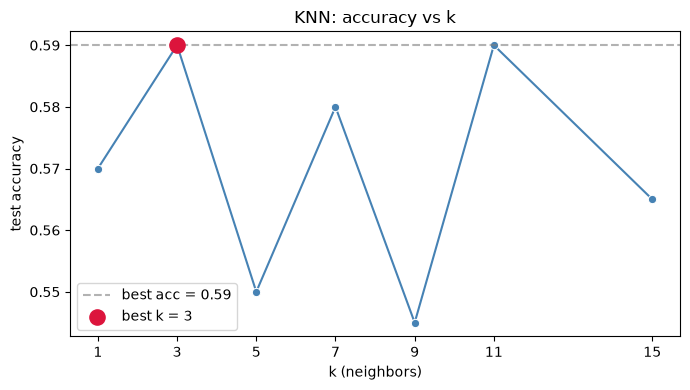

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(data=results_df, x="k", y="accuracy", marker="o", ax=ax, color="steelblue")
ax.axhline(best_acc, color="gray", linestyle="--", alpha=0.6, label=f"best acc = {best_acc:.2f}")
ax.scatter([best_k], [best_acc], color="crimson", s=120, zorder=5, label=f"best k = {best_k}")
ax.set_xlabel("k (neighbors)")
ax.set_ylabel("test accuracy")
ax.set_title("KNN: accuracy vs k")
ax.set_xticks(k_values)
ax.legend()
plt.tight_layout()
plt.show()


### Reading the curve

- **k=1** (~0.57): very local — sensitive to noisy neighbors.
- **k=5** (0.55): Lab 2 default — not optimal here.
- **k=15** (~0.57): smoother boundary — may miss local default patterns.
- **k=3** (0.59): best balance for this dataset and split.

### 4b. Bar chart alternative

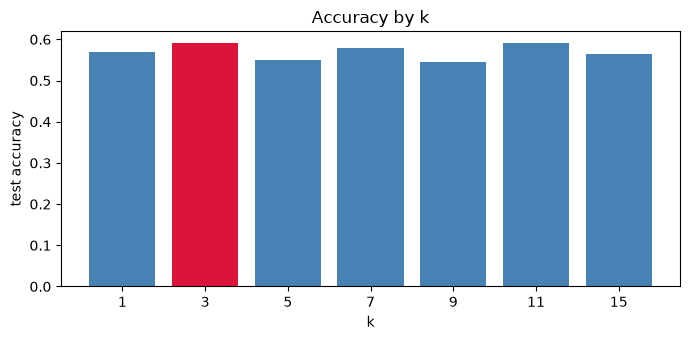

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["crimson" if k == best_k else "steelblue" for k in results_df["k"]]
ax.bar(results_df["k"].astype(str), results_df["accuracy"], color=colors)
ax.set_xlabel("k")
ax.set_ylabel("test accuracy")
ax.set_title("Accuracy by k")
plt.tight_layout()
plt.show()


### 4c. Annotate each point

In [10]:
for _, row in results_df.iterrows():
    print(f"k={int(row['k']):2d}  accuracy={row['accuracy']:.4f}{'  *' if row['best'] else ''}")


k= 1  accuracy=0.5700
k= 3  accuracy=0.5900  *
k= 5  accuracy=0.5500
k= 7  accuracy=0.5800
k= 9  accuracy=0.5450
k=11  accuracy=0.5900
k=15  accuracy=0.5650


### 4d. Accuracy range across sweep

In [11]:
acc_min, acc_max = results_df["accuracy"].min(), results_df["accuracy"].max()
print(f"accuracy range: {acc_min:.4f} – {acc_max:.4f} (span {acc_max - acc_min:.4f})")


accuracy range: 0.5450 – 0.5900 (span 0.0450)


---

## 5. Compare to Lab 2 (k=5)

In [12]:
acc_k5 = next(acc for k, acc in results if k == 5)
improvement = best_acc - acc_k5

compare = pd.DataFrame({
    "setting": ["Lab 2 (k=5)", f"Lab 3 (k={best_k})"],
    "accuracy": [acc_k5, best_acc],
})
display(compare.round(4))
print(f"improvement over k=5: {improvement:+.4f}")


,setting,accuracy
0,Lab 2 (k=5),0.55
1,Lab 3 (k=3),0.59


improvement over k=5: +0.0400


### 5b. Compare to Day 3 logistic regression

In [13]:
print("Day 3 logistic regression (typical): ~0.59")
print(f"Best KNN k={best_k}: {best_acc:.4f}")
print("KNN can match linear models when k is tuned.")


Day 3 logistic regression (typical): ~0.59
Best KNN k=3: 0.5900
KNN can match linear models when k is tuned.


---

## 6. Bias–variance discussion

| k | Variance | Bias | Accuracy trend (this lab) |
|---|----------|------|---------------------------|
| 1 | High | Low | Moderate — noisy votes |
| 3 | Balanced | Balanced | **Best** |
| 15 | Low | High | Moderate — oversmoothed |

### 6b. What if k = len(X_train)?

In [14]:
majority_class = int(y_train.mode()[0])
majority_acc = (y_test == majority_class).mean()
print(f"Majority-class baseline accuracy: {majority_acc:.4f}")
print(f"k = {len(X_train)} would predict majority class for every point.")


Majority-class baseline accuracy: 0.5150
k = 800 would predict majority class for every point.


### 6c. Train accuracy vs test accuracy at best k

In [15]:
best_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k)),
])
best_pipe.fit(X_train, y_train)
train_acc = accuracy_score(y_train, best_pipe.predict(X_train))
print(f"k={best_k} train accuracy: {train_acc:.4f}")
print(f"k={best_k} test accuracy:  {best_acc:.4f}")
print(f"gap (overfit signal): {train_acc - best_acc:+.4f}")


k=3 train accuracy: 0.7438


k=3 test accuracy:  0.5900
gap (overfit signal): +0.1538


### 6d. Odd vs even k

In [16]:
odd_ks = [k for k in k_values if k % 2 == 1]
even_ks = [k for k in k_values if k % 2 == 0]
print("Odd k values:", odd_ks)
print("Even k values:", even_ks, "(none in this sweep — ties less likely)")


Odd k values: [1, 3, 5, 7, 9, 11, 15]
Even k values: [] (none in this sweep — ties less likely)


### 6e. Export sweep results

In [17]:
results_df.to_csv("knn_k_sweep.csv", index=False)
print("Saved knn_k_sweep.csv (optional classroom artifact)")


Saved knn_k_sweep.csv (optional classroom artifact)

---

## 7. Cross-validation preview (concept)

Instead of one train/test split, `cross_val_score` averages accuracy across folds. That gives a stabler estimate of k before touching the test set.

In [18]:
from sklearn.model_selection import cross_val_score
cv_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=3)),
])
cv_scores = cross_val_score(cv_pipe, X_train, y_train, cv=5, scoring="accuracy")
print(f"5-fold CV accuracy (k=3): mean={cv_scores.mean():.4f}, std={cv_scores.std():.4f}")


5-fold CV accuracy (k=3): mean=0.5188, std=0.0342


### 7b. CV for multiple k values

In [19]:
cv_summary = []
for k_cv in [3, 5, 7]:
    p = Pipeline([("scale", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k_cv))])
    scores = cross_val_score(p, X_train, y_train, cv=5, scoring="accuracy")
    cv_summary.append({"k": k_cv, "cv_mean": scores.mean(), "cv_std": scores.std()})
display(pd.DataFrame(cv_summary).round(4))


,k,cv_mean,cv_std
0,3,0.5188,0.0342
1,5,0.5162,0.0287
2,7,0.5388,0.0242


### 7c. Best k from CV vs test sweep

In [20]:
best_cv_k = max(cv_summary, key=lambda x: x["cv_mean"])["k"]
print(f"Best k by CV mean: {best_cv_k}")
print(f"Best k by test sweep: {best_k}")


Best k by CV mean: 7
Best k by test sweep: 3


### 7d. Confusion matrix at best k

In [21]:
from sklearn.metrics import confusion_matrix
y_best = best_pipe.predict(X_test)
print("Confusion matrix (k=best):\n", confusion_matrix(y_test, y_best))


Confusion matrix (k=best):
 [[59 44]
 [38 59]]


### 7e. Elbow-style interpretation

Look for the **smallest k** that reaches near-peak accuracy — here k=3 before gains flatten. Avoid chasing tiny improvements that may not generalize.

---

## 8. Production note — validation vs test

This lab sweeps k on the **test** set for classroom simplicity. In production:

1. Split **train / validation / test**.
2. Pick k on **validation** only.
3. Report final metrics on **test** once.

### 8b. Hyperparameter search with GridSearchCV (preview)

In [22]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(
    Pipeline([("scale", StandardScaler()), ("knn", KNeighborsClassifier())]),
    param_grid={"knn__n_neighbors": k_values},
    cv=3,
    scoring="accuracy",
)
grid.fit(X_train, y_train)
print(f"GridSearchCV best k: {grid.best_params_['knn__n_neighbors']}")
print(f"GridSearchCV best CV score: {grid.best_score_:.4f}")


GridSearchCV best k: 9
GridSearchCV best CV score: 0.5425


---

## 9. Try it yourself

Add k=21 to the sweep. Does accuracy improve or degrade?

In [23]:
# Your code here (optional)


In [24]:
pipe_21 = Pipeline([
    ("scale", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=21)),
])
pipe_21.fit(X_train, y_train)
acc_21 = accuracy_score(y_test, pipe_21.predict(X_test))
print(f"k=21 accuracy: {acc_21:.4f} (best was k={best_k} at {best_acc:.4f})")


k=21 accuracy: 0.6050 (best was k=3 at 0.5900)


---

## 10. Checkpoint summary

In [25]:
assert len(k_values) == 7
assert len(results) == 7
assert best_k == 3
assert abs(best_acc - 0.59) < 0.02
acc_by_k = dict(results)
assert abs(acc_by_k[5] - 0.55) < 0.02
print("Numbers match — you're good.")



Numbers match — you're good.


---

## Reflection

1. Why is evaluating many k values on the **test** set a simplification?
2. What would you expect at k = len(X_train)?
3. Labs 4–6 reuse tuned values — why log the chosen k in MLflow (Lab 6)?
